# Plots

## Task 0
Serial implementation of matrix-matrix multiplication

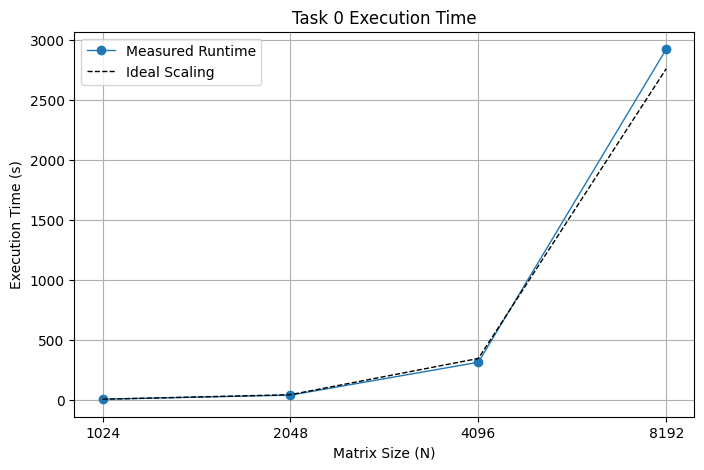

In [154]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

x_labels = np.array([1024, 2048, 4096, 8192])
y = np.array([5.390282, 39.574156, 313.427331, 2922.320500])

x_pos = np.arange(len(x_labels))
ideal = y[0] * (x_labels / x_labels[0])**3

plt.figure(figsize=(8, 5))
plt.plot(x_pos, y, marker='o', linewidth=1, label='Measured Runtime')
plt.plot(x_pos, ideal, linestyle='--', linewidth=1, color='black', label='Ideal Scaling')
plt.xticks(x_pos, x_labels)

plt.xlabel('Matrix Size (N)')
plt.ylabel('Execution Time (s)')
plt.title('Task 0 Execution Time')

plt.grid(True)
plt.legend()

plt.show()

## Task 1
Shared memory implementation of matrix-matrix multiplication using OpenMPI

### Strong Scaling

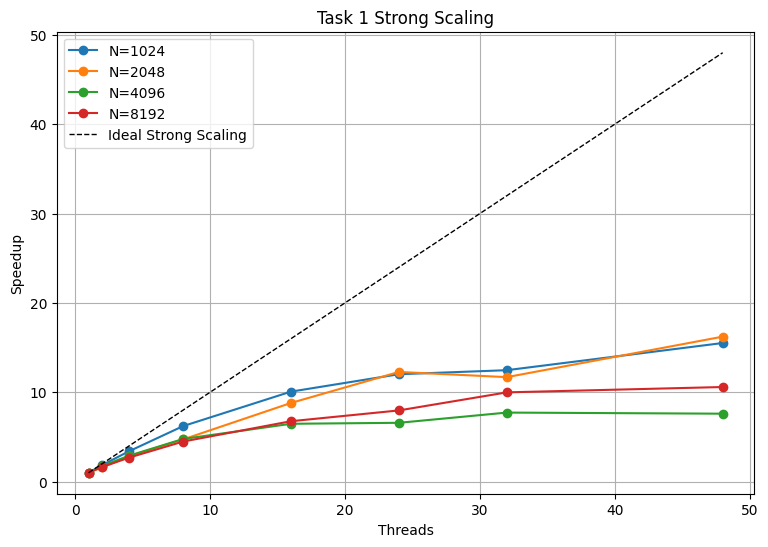

In [155]:
threads = [1, 2, 4, 8, 16, 24, 32, 48]

data = {
    1024: [0.154669, 0.083439, 0.045447, 0.024886, 0.015352, 0.012866, 0.012399, 0.009969],
    2048: [1.529915, 0.943513, 0.535733, 0.323823, 0.173729, 0.124613, 0.130810, 0.094285],
    4096: [23.590915, 13.401344, 8.118061, 4.941680, 3.642184, 3.581980, 3.051997, 3.101185],
    8192: [184.831581, 113.518914, 68.634289, 41.191042, 27.328564, 23.186104, 18.497726, 17.452736]
}

plt.figure(figsize=(9,6))

for N, times in data.items():
    t1 = times[0]
    speedup = [t1 / t for t in times]
    plt.plot(threads, speedup, marker='o', label=f"N={N}")

ideal = threads
plt.plot(threads, ideal, linestyle='--', linewidth=1, color='black', label="Ideal Strong Scaling")

plt.xlabel("Threads")
plt.ylabel("Speedup")
plt.title("Task 1 Strong Scaling")

plt.grid(True)
plt.legend()

plt.show()

### Weak Scaling

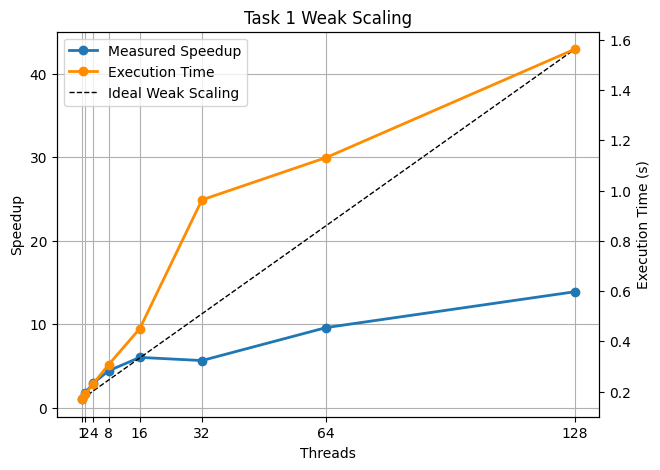

In [156]:
threads = [1, 2, 4, 8, 16, 32, 64, 128]
time = [0.169269, 0.190036, 0.231282, 0.307162, 0.450719, 0.962814, 1.131244, 1.562475]

speedup = [1, 1.78, 2.93, 4.41, 6.01, 5.63, 9.58, 13.87]

fig, ax1 = plt.subplots(figsize=(7,5))

line1, = ax1.plot(threads, speedup, marker='o', linewidth=2, label="Measured Speedup")

ideal = [float(t) * 0.33 + 0.67 for t in threads]

line2, = ax1.plot(threads, ideal, linestyle='--', linewidth=1, color='black', label="Ideal Weak Scaling")

ax1.set_xlabel("Threads")
ax1.set_ylabel("Speedup")
ax1.set_xticks(threads)
ax1.grid(True)

ax2 = ax1.twinx()

line3, = ax2.plot(threads, time, marker='o', linewidth=2, color='darkorange', label="Execution Time")

ax2.set_ylabel("Execution Time (s)")

ax1.legend([line1, line3, line2], ["Measured Speedup", "Execution Time", "Ideal Weak Scaling"], loc='upper left')

plt.title("Task 1 Weak Scaling")

plt.show()

## Task 2
Distributed memory implementation of matrix-matrix multiplication using MPI

### Strong Scaling


STRONG SCALING FOR N = 1024
 np     1024  speedup_1024  ideal_1024
 16 0.017380      1.000000         1.0
 32 0.008467      2.052675         2.0
 64 0.005688      3.055556         4.0
128 0.003971      4.376731         8.0

STRONG SCALING FOR N = 2048
 np     2048  speedup_2048  ideal_2048
 16 0.134869      1.000000         1.0
 32 0.070938      1.901224         2.0
 64 0.056691      2.379020         4.0
128 0.051742      2.606567         8.0

STRONG SCALING FOR N = 4096
 np     4096  speedup_4096  ideal_4096
 16 1.559307      1.000000         1.0
 32 0.872356      1.787466         2.0
 64 0.585840      2.661660         4.0
128 0.553009      2.819677         8.0

STRONG SCALING FOR N = 8192
 np      8192  speedup_8192  ideal_8192
 16 15.458689      1.000000         1.0
 32  8.705657      1.775706         2.0
 64  5.733643      2.696137         4.0
128  5.458680      2.831946         8.0


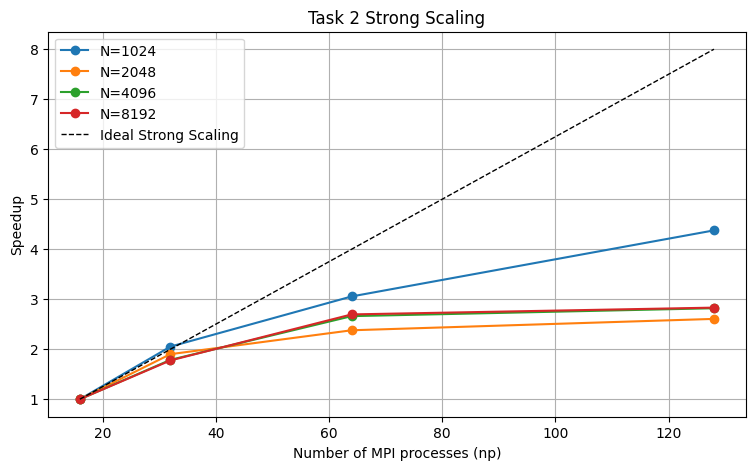

In [157]:
data = {
    "np": [16, 32, 64, 128],
    "1024": [0.017380, 0.008467, 0.005688, 0.003971],
    "2048": [0.134869, 0.070938, 0.056691, 0.051742],
    "4096": [1.559307, 0.872356, 0.585840, 0.553009],
    "8192": [15.458689, 8.705657, 5.733643, 5.458680],
}

df = pd.DataFrame(data)

sizes = ["1024", "2048", "4096", "8192"]

plt.figure(figsize=(9, 5))

for N in sizes:

    T_base = df.loc[df["np"] == 16, N].iloc[0]
    P_base = 16

    # Measured speedup
    df[f"speedup_{N}"] = T_base / df[N]

    # Ideal speedup
    df[f"ideal_{N}"] = df["np"] / P_base

    print(f"\n==============================")
    print(f"STRONG SCALING FOR N = {N}")
    print("==============================")

    print(
        df[
            ["np", N, f"speedup_{N}", f"ideal_{N}"]
        ].to_string(index=False)
    )

    # Plot measured speedup
    plt.plot(df["np"], df[f"speedup_{N}"], marker="o", label=f"N={N}")

# Plot ideal scaling
ideal_speedup = df["np"] / 16

plt.plot(df["np"], ideal_speedup, linestyle="--", linewidth=1, color="black", label="Ideal Strong Scaling")

plt.xlabel("Number of MPI processes (np)")
plt.ylabel("Speedup")
plt.title("Task 2 Strong Scaling")

plt.grid(True)
plt.legend()

plt.show()

### Weak Scaling

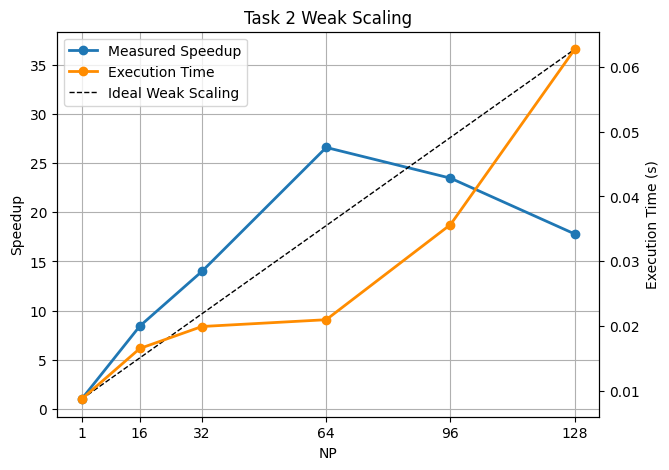

In [158]:
NP = [1, 16, 32, 64, 96, 128]
time = [0.008714, 0.016542, 0.019932, 0.020979, 0.035651, 0.062707]

speedup = [1, 8.43, 13.99, 26.58, 23.46, 17.79]

fig, ax1 = plt.subplots(figsize=(7,5))

line1, = ax1.plot(NP, speedup, marker='o', linewidth=2, label="Measured Speedup")

ideal = [float(t) * 0.28 + 0.72 for t in NP]

line2, = ax1.plot(NP, ideal, linestyle='--', linewidth=1, color='black', label="Ideal Weak Scaling")

ax1.set_xlabel("NP")
ax1.set_ylabel("Speedup")
ax1.set_xticks(NP)
ax1.grid(True)

ax2 = ax1.twinx()

line3, = ax2.plot(NP, time, marker='o', linewidth=2, color='darkorange', label="Execution Time")

ax2.set_ylabel("Execution Time (s)")

ax1.legend([line1, line3, line2], ["Measured Speedup", "Execution Time", "Ideal Weak Scaling"], loc='upper left')

plt.title("Task 2 Weak Scaling")

plt.show()

## Task 3
Matrix-matrix multiplication with GPU acceleration using CUDA

### Strong Scaling


STRONG SCALING FOR 18 SMs

------------------------------
N = 1024
------------------------------
 multiplier  grid_blocks     1024  speedup  ideal_speedup
          1           18 0.037968 1.000000            1.0
          2           36 0.019387 1.958426            2.0
          3           54 0.013122 2.893461            3.0
          4           72 0.010311 3.682281            4.0

------------------------------
N = 2048
------------------------------
 multiplier  grid_blocks     2048  speedup  ideal_speedup
          1           18 0.641456 1.000000            1.0
          2           36 0.320630 2.000611            2.0
          3           54 0.213969 2.997892            3.0
          4           72 0.160528 3.995913            4.0

------------------------------
N = 4096
------------------------------
 multiplier  grid_blocks     4096  speedup  ideal_speedup
          1           18 5.243005 1.000000            1.0
          2           36 2.610076 2.008756            2.0
   

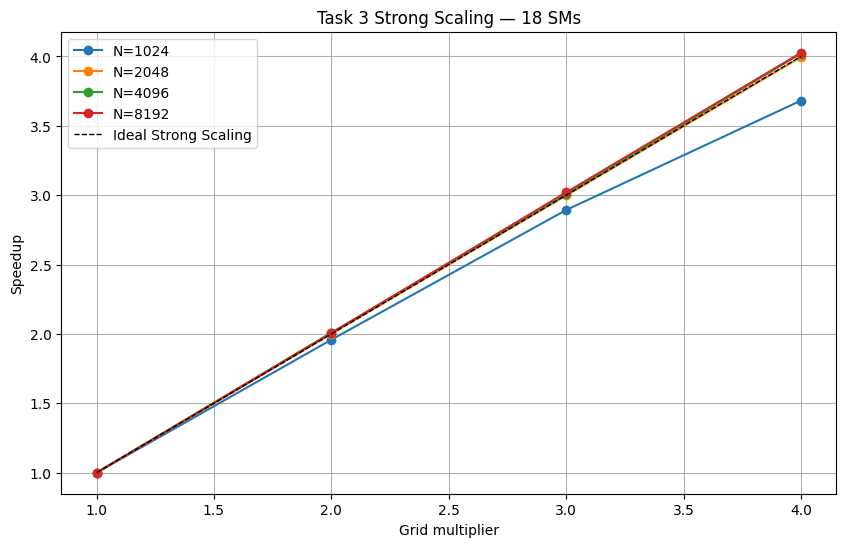


STRONG SCALING FOR 148 SMs

------------------------------
N = 1024
------------------------------
 multiplier  grid_blocks     1024  speedup  ideal_speedup
          1          148 0.004989 1.000000            1.0
          2          296 0.002645 1.886200            2.0
          3          444 0.001859 2.683701            3.0
          4          592 0.001461 3.414784            4.0
          5          740 0.001445 3.452595            5.0

------------------------------
N = 2048
------------------------------
 multiplier  grid_blocks     2048  speedup  ideal_speedup
          1          148 0.039304 1.000000            1.0
          2          296 0.020301 1.936062            2.0
          3          444 0.013760 2.856395            3.0
          4          592 0.010988 3.576993            4.0
          5          740 0.010997 3.574066            5.0

------------------------------
N = 4096
------------------------------
 multiplier  grid_blocks     4096  speedup  ideal_speedup
  

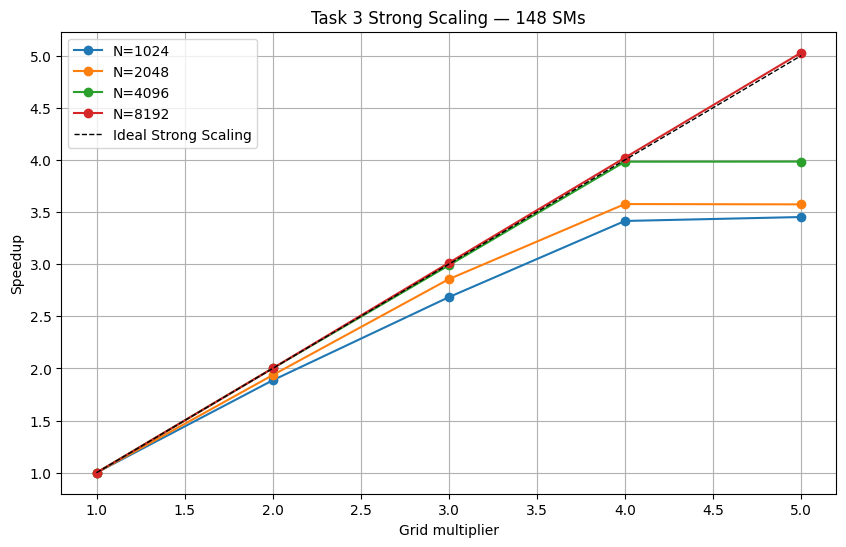

In [159]:
data = {
    "threads": [128,128,128,128,128,128,128,128,128],
    "SMs": [18,18,18,18,148,148,148,148,148],
    "multiplier": [1,2,3,4,1,2,3,4,5],
    "grid_blocks": [18,36,54,72,148,296,444,592,740],
    "1024": [0.037968,0.019387,0.013122,0.010311,0.004989,0.002645,0.001859,0.001461,0.001445],
    "2048": [0.641456,0.320630,0.213969,0.160528,0.039304,0.020301,0.013760,0.010988,0.010997],
    "4096": [5.243005,2.610076,1.743498,1.303912,0.712482,0.356068,0.238384,0.178875,0.178826],
    "8192": [42.599354,21.227369,14.104342,10.579220,6.002107,2.998679,1.992197,1.492445,1.193614]
}

df = pd.DataFrame(data)

sizes = ["1024", "2048", "4096", "8192"]

for sm in sorted(df["SMs"].unique()):

    df_sm = df[df["SMs"] == sm].copy()

    plt.figure(figsize=(10, 6))

    print("\n===================================")
    print(f"STRONG SCALING FOR {sm} SMs")
    print("===================================")

    for N in sizes:

        strong = df_sm[["multiplier", "grid_blocks", N]].dropna().sort_values("multiplier")

        T_base = strong[N].iloc[0]
        P_base = strong["multiplier"].iloc[0]

        strong["speedup"] = T_base / strong[N]
        strong["ideal_speedup"] = strong["multiplier"] / P_base

        print("\n------------------------------")
        print(f"N = {N}")
        print("------------------------------")
        print(strong.to_string(index=False))

        plt.plot(strong["multiplier"], strong["speedup"], marker="o", label=f"N={N}")

    ideal_x = df_sm["multiplier"].sort_values()
    ideal_y = ideal_x / ideal_x.iloc[0]

    plt.plot(ideal_x, ideal_y, linestyle="--", linewidth=1, color="black", label="Ideal Strong Scaling")

    plt.xlabel("Grid multiplier")
    plt.ylabel("Speedup")
    plt.title(f"Task 3 Strong Scaling — {sm} SMs")

    plt.grid(True)
    plt.legend()

    plt.show()

### Weak Scaling


Weak Scaling Efficiency (%)
 multiplier  1024_to_2048  2048_to_4096  4096_to_8192
          1     96.600855     90.031187     87.352741
          2     95.497759     90.047407     87.040860
          3     95.363372     89.758121     87.516345
          4     93.838733     89.743117     87.367508


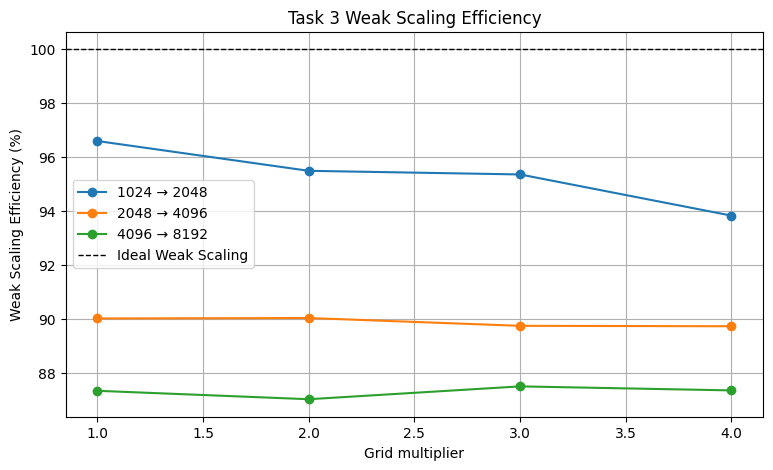

In [160]:
data = {
    "multiplier": [1, 2, 3, 4],
    "1024_to_2048": [
        0.037968 / 0.039304,
        0.019387 / 0.020301,
        0.013122 / 0.013760,
        0.010311 / 0.010988
    ],
    "2048_to_4096": [
        0.641456 / 0.712482,
        0.320630 / 0.356068,
        0.213969 / 0.238384,
        0.160528 / 0.178875
    ],
    "4096_to_8192": [
        5.243005 / 6.002107,
        2.610076 / 2.998679,
        1.743498 / 1.992197,
        1.303912 / 1.492445
    ]
}

df = pd.DataFrame(data)

for col in df.columns:
    if col != "multiplier":
        df[col] = df[col] * 100

print("\nWeak Scaling Efficiency (%)")
print(df.to_string(index=False))

# Plot
plt.figure(figsize=(9, 5))

plt.plot(df["multiplier"], df["1024_to_2048"], marker="o", label="1024 → 2048")
plt.plot(df["multiplier"], df["2048_to_4096"], marker="o", label="2048 → 4096")
plt.plot(df["multiplier"], df["4096_to_8192"], marker="o", label="4096 → 8192")

plt.axhline(100, linestyle="--", linewidth=1, color='black', label="Ideal Weak Scaling")

plt.xlabel("Grid multiplier")
plt.ylabel("Weak Scaling Efficiency (%)")
plt.title("Task 3 Weak Scaling Efficiency")

plt.grid(True)
plt.legend()

plt.show()

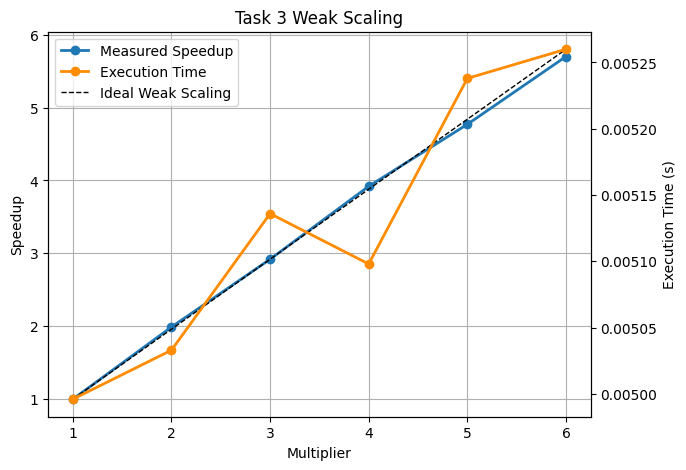

In [165]:
multiplier = [1, 2, 3, 4, 5, 6]
time = [0.004996, 0.005033, 0.005136, 0.005098, 0.005238, 0.005260]

speedup = [1, 1.99, 2.92, 3.92, 4.77, 5.70]

fig, ax1 = plt.subplots(figsize=(7,5))

line1, = ax1.plot(multiplier, speedup, marker='o', linewidth=2, label="Measured Speedup")

ideal = [float(t) * 0.96 + 0.04 for t in multiplier]

line2, = ax1.plot(multiplier, ideal, linestyle='--', linewidth=1, color='black', label="Ideal Weak Scaling")

ax1.set_xlabel("Multiplier")
ax1.set_ylabel("Speedup")
ax1.set_xticks(multiplier)
ax1.grid(True)

ax2 = ax1.twinx()

line3, = ax2.plot(multiplier, time, marker='o', linewidth=2, color='darkorange', label="Execution Time")

ax2.set_ylabel("Execution Time (s)")

ax1.legend([line1, line3, line2], ["Measured Speedup", "Execution Time", "Ideal Weak Scaling"], loc='upper left')

plt.title("Task 3 Weak Scaling")

plt.show()

### Tile Implementation


CUDA Matrix Multiplication Results

   N  Naive (ms)  Tile 8 (ms)  Tile 8 Speedup  Tile 16 (ms)  Tile 16 Speedup  Tile 32 (ms)  Tile 32 Speedup
1024       0.704        0.544           1.294         0.394            1.787         0.363            1.938
2048       4.020        3.198           1.257         2.064            1.948         1.845            2.179
4096      35.266       24.170           1.459        15.170            2.325        13.430            2.626


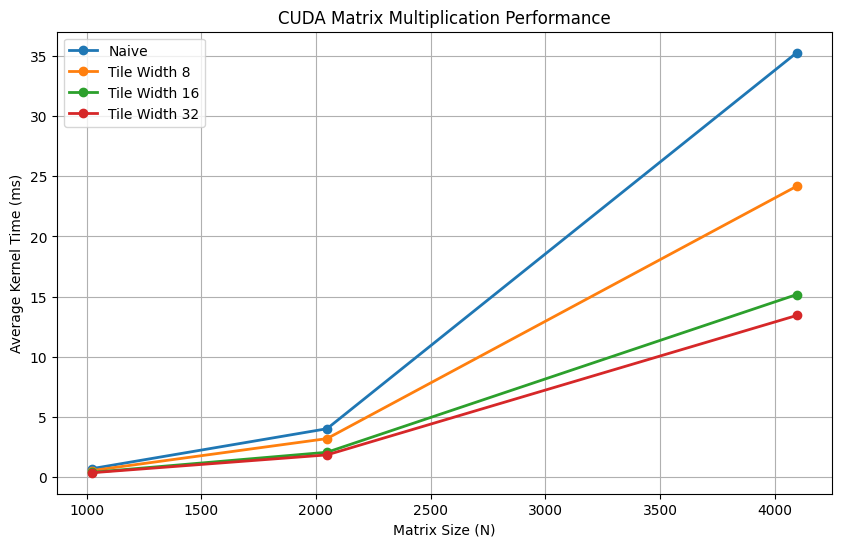

In [161]:
N = [1024, 2048, 4096]

naive = [0.704, 4.020, 35.266]
tile8 = [0.544256, 3.198241, 24.170176]
tile16 = [0.393852, 2.064043, 15.169878]
tile32 = [0.363184, 1.844566, 13.430153]

# Compute speedups relative to naive implementation
speedup8 = [n/t for n, t in zip(naive, tile8)]
speedup16 = [n/t for n, t in zip(naive, tile16)]
speedup32 = [n/t for n, t in zip(naive, tile32)]

# Create dataframe
df = pd.DataFrame({
    'N': N,
    'Naive (ms)': naive,
    'Tile 8 (ms)': tile8,
    'Tile 8 Speedup': speedup8,
    'Tile 16 (ms)': tile16,
    'Tile 16 Speedup': speedup16,
    'Tile 32 (ms)': tile32,
    'Tile 32 Speedup': speedup32
})

# Round values for cleaner output
df = df.round(3)

# Print table
print("\nCUDA Matrix Multiplication Results\n")
print(df.to_string(index=False))

# Plot
plt.figure(figsize=(10,6))

plt.plot(N, naive, marker='o', linewidth=2, label='Naive')
plt.plot(N, tile8, marker='o', linewidth=2, label='Tile Width 8')
plt.plot(N, tile16, marker='o', linewidth=2, label='Tile Width 16')
plt.plot(N, tile32, marker='o', linewidth=2, label='Tile Width 32')

plt.xlabel('Matrix Size (N)')
plt.ylabel('Average Kernel Time (ms)')
plt.title('CUDA Matrix Multiplication Performance')

plt.grid(True)
plt.legend()

plt.show()

## Performance Comparison

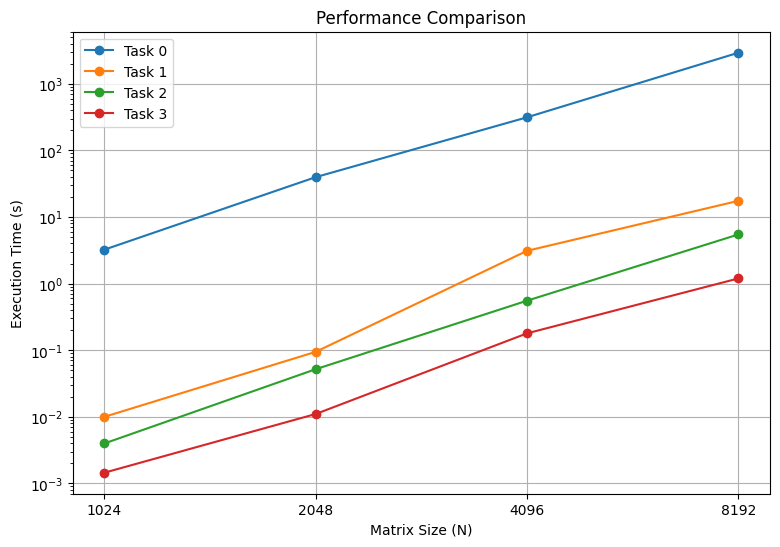

In [162]:
N = [1024, 2048, 4096, 8192]
x = range(len(N))

# Execution times
task0 = [3.225624, 39.574156, 313.427331, 2922.320500]
task1 = [0.009969, 0.094285, 3.101185, 17.452736]
task2 = [0.003971, 0.051742, 0.553009, 5.458680]
task3 = [0.001445, 0.010997, 0.178826, 1.193614]

plt.figure(figsize=(9, 6))

plt.plot(x, task0, marker='o', label='Task 0')
plt.plot(x, task1, marker='o', label='Task 1')
plt.plot(x, task2, marker='o', label='Task 2')
plt.plot(x, task3, marker='o', label='Task 3')

plt.xticks(x, N)
plt.xlabel("Matrix Size (N)")

plt.yscale("log")

plt.ylabel("Execution Time (s)")
plt.title("Performance Comparison")

plt.grid(True)
plt.legend()

plt.show()